## imports & Setup


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# ── Fix random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Output directory for saved files
OUT_DIR = Path("outputs")
OUT_DIR.mkdir(exist_ok=True)

print("Setup complete ✅")

Setup complete ✅


## Configuration

All hyperparameters in one place for easy tuning.

In [3]:
# ── File settings
FILE_PATH     = "/content/drive/MyDrive/Colab Notebooks/electricity_demand_srilanka_fixed.csv"
TARGET_COL    = "Load Demand (kW)"      # column we want to predict
TIMESTAMP_COL = "Timestamp"             # datetime column

# ── Sequence parameters
LOOKBACK  = 168    # 96 × 15 min = 24 hours of history per sample
HORIZON   = 4     # predict 1 step (15 min) ahead

# ── Train / val / test split
TRAIN_RATIO = 0.70   # 80% train
VAL_RATIO   = 0.15   # 15% val  — also used as conformal calibration set
                     # remaining 15% = test

# ── Training hyperparameters
BATCH_SIZE = 128
MAX_EPOCHS = 100
LR         = 1e-3    # Adam initial learning rate

# ── MC Dropout settings
MC_SAMPLES = 100     # stochastic forward passes at inference
DROP_RATE  = 0.1     # dropout probability at both Dropout layers

## Load Data

In [4]:
# ── Load CSV and parse timestamps
df = pd.read_csv(FILE_PATH, parse_dates=[TIMESTAMP_COL])
df = df.sort_values(TIMESTAMP_COL).reset_index(drop=True)
df = df.set_index(TIMESTAMP_COL)


print(f"Dataset shape : {df.shape}")
print(f"Date range    : {df.index[0]}  →  {df.index[-1]}")
df.head(3)

Dataset shape : (189888, 16)
Date range    : 2020-01-01 00:00:00  →  2025-05-31 23:45:00


,Unnamed: 0,Temperature (°C),Humidity (%),Wind Speed (m/s),Rainfall (mm),Solar Irradiance (W/m²),GDP (LKR),Per Capita Energy Use (kWh),Electricity Price (LKR/kWh),Day of Week,Hour of Day,Month,Season,Public Event,Load Demand (kW),Poya Day
Timestamp,,,,,,,,,,,,,,,,
2020-01-01 00:00:00,0,28.993428,75.011269,1.053861,4.140513,185.892561,925.621430,502.915605,20.454440,2,0,1,Summer,0,1202.4797,0
2020-01-01 00:15:00,1,27.723471,77.024015,1.085152,9.446997,281.782650,1020.823521,497.286366,27.776449,2,0,1,Summer,0,1213.1439,0
2020-01-01 00:30:00,2,29.295377,74.732958,3.363800,4.265813,328.942058,1028.847455,488.816292,21.097420,2,0,1,Summer,0,1215.3267,0


## Feature Engineering

We build two types of features:

**Cyclic time features** — sine/cosine encoding ensures circular continuity:
  - Hour 23 and Hour 0 are *adjacent* in the encoded space (no jump)

**Lag & rolling features** — historical load values anchored ≥ 24h behind the target:
  - All lags use `shift(96)` or more → **zero data leakage**

In [5]:
# ── Cyclic time encodings (sine/cosine pairs for circular continuity)
df["sin_hour"]  = np.sin(2 * np.pi * df["Hour of Day"] / 24)
df["cos_hour"]  = np.cos(2 * np.pi * df["Hour of Day"] / 24)
df["sin_dow"]   = np.sin(2 * np.pi * df["Day of Week"] / 7)
df["cos_dow"]   = np.cos(2 * np.pi * df["Day of Week"] / 7)
df["sin_month"] = np.sin(2 * np.pi * df["Month"] / 12)
df["cos_month"] = np.cos(2 * np.pi * df["Month"] / 12)

# ── Weekend flag — Sat (5) / Sun (6) have lower industrial load
df["is_weekend"] = (df["Day of Week"] >= 5).astype(int)

# ── Trend signal — Sri Lanka demand has trended up since 2022
# Normalised to [0, 1] over training window
# Update denominator annually: /4 in 2026, /5 in 2027
df["year_norm"] = (df.index.year - 2022) / 3

# ── Lag features — ALL shifted ≥ 96 steps (24h) → no leakage
df["load_lag_96"]  = df[TARGET_COL].shift(96)      # 24 hours ago
df["load_lag_192"] = df[TARGET_COL].shift(192)     # 48 hours ago
df["load_lag_672"] = df[TARGET_COL].shift(96 * 7) # 1 week ago

# ── Rolling statistics anchored at 24h ago (zero leakage)
df["load_mean_week"] = df[TARGET_COL].shift(96).rolling(96 * 7).mean()  # 7-day mean
df["load_std_day"]   = df[TARGET_COL].shift(96).rolling(96).std()       # 24h std

# ── Drop NaN rows created by lag/rolling (first ~672 rows)
df.dropna(inplace=True)
print(f"Rows after dropna: {len(df):,}")

Rows after dropna: 189,121


In [6]:
# ── Define final feature list
FEATURE_COLS = [
    # Weather
    "Temperature (°C)", "Humidity (%)", "Wind Speed (m/s)",
    "Rainfall (mm)", "Solar Irradiance (W/m²)",
    # Cyclic time
    "sin_hour", "cos_hour", "sin_dow", "cos_dow",
    "sin_month", "cos_month", "is_weekend", "year_norm",
    # Calendar events (suppress demand)
    "Public Event", "Poya Day",
    # Historical load (lag / rolling)
    "load_lag_96", "load_lag_192", "load_lag_672",
    "load_mean_week", "load_std_day",
]

# Keep only columns that exist in the dataframe (defensive guard)
FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]

print(f"Total features : {len(FEATURE_COLS)}")
print(f"Feature list   : {FEATURE_COLS}")

Total features : 20
Feature list   : ['Temperature (°C)', 'Humidity (%)', 'Wind Speed (m/s)', 'Rainfall (mm)', 'Solar Irradiance (W/m²)', 'sin_hour', 'cos_hour', 'sin_dow', 'cos_dow', 'sin_month', 'cos_month', 'is_weekend', 'year_norm', 'Public Event', 'Poya Day', 'load_lag_96', 'load_lag_192', 'load_lag_672', 'load_mean_week', 'load_std_day']


## Leakage Sanity Check

We check **Pearson correlation** of each feature with the target.

>  Correlation > 0.98 = potential data leakage → must investigate
>
> High-lag features like `load_lag_96` (~0.88) are expected to be high — they are **legitimate** same-time historical values, not leakage.

In [7]:
print(f"{'Feature':<35}  Correlation with Target")
print("-" * 65)

for col in FEATURE_COLS:
    corr = df[col].corr(df[TARGET_COL])
    flag = "  ⚠️  HIGH — CHECK FOR LEAKAGE" if abs(corr) > 0.98 else ""
    print(f"  {col:<35} {corr:+.4f}{flag}")

Feature                              Correlation with Target
-----------------------------------------------------------------
  Temperature (°C)                    +0.0132
  Humidity (%)                        +0.0015
  Wind Speed (m/s)                    +0.0016
  Rainfall (mm)                       -0.0024
  Solar Irradiance (W/m²)             -0.0044
  sin_hour                            +0.0636
  cos_hour                            -0.6127
  sin_dow                             +0.1589
  cos_dow                             -0.1787
  sin_month                           +0.2942
  cos_month                           -0.0485
  is_weekend                          -0.2134
  year_norm                           +0.6628
  Public Event                        -0.0642
  Poya Day                            -0.1162
  load_lag_96                         +0.9139
  load_lag_192                        +0.8584
  load_lag_672                        +0.9505
  load_mean_week                      +0.6981

## Temporal Split & Scaling

**Important rules for time series:**

1. **Never shuffle** — always split chronologically
2. **Fit scalers on train only** — fitting on all data leaks future statistics
3. **StandardScaler over MinMaxScaler** — demand trends upward, so test values may exceed the training max; StandardScaler is robust to this drift

In [8]:
n       = len(df)
n_train = int(n * TRAIN_RATIO)
n_val   = int(n * VAL_RATIO)

# ── Chronological split (no shuffling!)
df_train = df.iloc[:n_train]
df_val   = df.iloc[n_train : n_train + n_val]
df_test  = df.iloc[n_train + n_val :]

print(f"Train : {len(df_train):,} samples  ({df_train.index[0].date()} → {df_train.index[-1].date()})")
print(f"Val   : {len(df_val):,} samples  ({df_val.index[0].date()} → {df_val.index[-1].date()})")
print(f"Test  : {len(df_test):,} samples  ({df_test.index[0].date()} → {df_test.index[-1].date()})")

Train : 132,384 samples  (2020-01-08 → 2023-10-18)
Val   : 28,368 samples  (2023-10-18 → 2024-08-09)
Test  : 28,369 samples  (2024-08-09 → 2025-05-31)


In [9]:
# ── Fit scalers on TRAINING data only, then apply to val/test
feat_scaler   = StandardScaler()
target_scaler = StandardScaler()

X_tr_raw = feat_scaler.fit_transform(df_train[FEATURE_COLS])      # fit + transform
y_tr_raw = target_scaler.fit_transform(df_train[[TARGET_COL]])

X_vl_raw = feat_scaler.transform(df_val[FEATURE_COLS])            # transform only!
y_vl_raw = target_scaler.transform(df_val[[TARGET_COL]])

X_te_raw = feat_scaler.transform(df_test[FEATURE_COLS])
y_te_raw = target_scaler.transform(df_test[[TARGET_COL]])

# ── Save scalers — required at deployment to invert predictions back to kW
joblib.dump(feat_scaler,   OUT_DIR / "feat_scaler.pkl")
joblib.dump(target_scaler, OUT_DIR / "target_scaler.pkl")
print("Scalers saved ✅")

Scalers saved ✅


## Build Sliding-Window Sequences

The model needs 3D input: `(samples, timesteps, features)`.

A sliding window is used:
- **X[i]** = features from step `i` to `i + 96` (24 hours of history)
- **y[i]** = target at step `i + 96` (the next 15-minute value)

In [10]:
def build_sequences(X, y, lookback, horizon=1):
    """
    Convert flat time-series arrays into overlapping (X, y) windows.

    Args:
        X        : 2D feature array  (timesteps × n_features)
        y        : 2D target array   (timesteps × 1)
        lookback : number of past steps used as model input
        horizon  : number of future steps to predict

    Returns:
        Xs : float32 array  (n_samples × lookback × n_features)
        ys : float32 array  (n_samples × horizon)
    """
    Xs, ys = [], []
    for i in range(len(X) - lookback - horizon + 1):
        Xs.append(X[i : i + lookback])
        ys.append(y[i + lookback : i + lookback + horizon, 0])
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)


X_tr, y_tr = build_sequences(X_tr_raw, y_tr_raw, LOOKBACK, HORIZON)
X_vl, y_vl = build_sequences(X_vl_raw, y_vl_raw, LOOKBACK, HORIZON)
X_te, y_te = build_sequences(X_te_raw, y_te_raw, LOOKBACK, HORIZON)

print(f"Train  X: {X_tr.shape}  y: {y_tr.shape}")
print(f"Val    X: {X_vl.shape}  y: {y_vl.shape}")
print(f"Test   X: {X_te.shape}  y: {y_te.shape}")

# ── Guard against silent bugs (e.g. all-zero sequences)
assert y_tr.std() > 0.01, "❌ Target variance near zero — check sequence building!"
print(f"\nTarget stats — mean: {y_tr.mean():.4f}  std: {y_tr.std():.4f}  ✅")

Train  X: (132213, 168, 20)  y: (132213, 4)
Val    X: (28197, 168, 20)  y: (28197, 4)
Test   X: (28198, 168, 20)  y: (28198, 4)

Target stats — mean: 0.0005  std: 1.0002  ✅


## Build the CNN-LSTM Model

**Why CNN + LSTM?**
- `Conv1D` with **causal padding** extracts local short-term patterns (morning ramp-up, evening peak) — causal means no future data leaks into the convolution
- `LSTM` layers learn long-range temporal dependencies (daily/weekly seasonality)

**Why Dropout at 0.1 (not 0.2–0.3)?**
> Higher dropout hurts convergence significantly. Rate 0.1 keeps training stable while still producing meaningful variance across MC passes.

**Dropout is placed AFTER the LSTM layers (not Conv layers):**
> Removing dropout from conv layers preserves feature quality and improves convergence speed.

In [11]:
n_steps    = LOOKBACK           # 96 timesteps
n_features = X_tr.shape[2]     # number of input features

# ── Input
inp = Input(shape=(n_steps, n_features), name="input")

# ── CNN block: extract local temporal patterns
# Causal padding ensures no future timestep leaks into convolution
x = Conv1D(filters=64, kernel_size=3, padding="causal", activation="relu", name="conv1")(inp)
x = Conv1D(filters=32, kernel_size=3, padding="causal", activation="relu", name="conv2")(x)

# ── LSTM block: model long-range dependencies across 24h window
x = LSTM(128, return_sequences=True,  name="lstm1")(x)   # pass all timesteps forward
x = LSTM(64,  return_sequences=False, name="lstm2")(x)   # final hidden state only

# ── Dropout after LSTM — PRIMARY source of MC uncertainty
# At training: Keras applies dropout normally
# At MC inference: we call model(X, training=True) to force it ON
x = Dropout(DROP_RATE, name="drop_lstm")(x)

# ── Dense projection + second Dropout layer
x = Dense(64, activation="relu", name="dense1")(x)
x = Dropout(DROP_RATE, name="drop_dense")(x)  # second MC uncertainty source

# ── Linear output (no activation for regression)
out = Dense(HORIZON, name="output")(x)

model = Model(inp, out, name="CNN_LSTM_MCDropout")
model.compile(optimizer=Adam(LR), loss="mae", metrics=["mae"])
model.summary()

Model: "CNN_LSTM_MCDropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 168, 20)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 168, 64)        │         3,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 168, 32)        │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm1 (LSTM)                    │ (None, 168, 128)       │        82,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm2 (LSTM)                    │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_lstm (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_dense (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 146,340 (571.64 KB)

 Trainable params: 146,340 (571.64 KB)

 Non-trainable params: 0 (0.00 B)

## 7️⃣ Train the Model

Three callbacks are used:

| Callback | Setting | Purpose |
|----------|---------|---------|
| `EarlyStopping` | patience=15 | Stop when val_loss stops improving; long patience survives LR reductions |
| `ReduceLROnPlateau` | factor=0.5, patience=8 | Halve learning rate when stuck |
| `ModelCheckpoint` | save_best_only | Save best weights to disk as safety net |

>  `shuffle=False` is **mandatory** for time-series — shuffling would cause future data to leak into training batches.

In [12]:
ckpt_path = str(OUT_DIR / "best_model.keras")

callbacks = [
    # Stop if val_loss doesn't improve for 15 epochs
    EarlyStopping(
        monitor="val_loss", patience=15,
        min_delta=1e-4, restore_best_weights=True, verbose=1
    ),
    # Halve LR every 8 epochs without val improvement
    ReduceLROnPlateau(
        monitor="val_loss", factor=0.5,
        patience=8, min_lr=1e-5, verbose=1
    ),
    # Save best weights to disk (independent safety net)
    ModelCheckpoint(
        ckpt_path, monitor="val_loss",
        save_best_only=True, verbose=0
    ),
]

history = model.fit(
    X_tr, y_tr,
    validation_data=(X_vl, y_vl),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    shuffle=False,      # MANDATORY — never shuffle time-series data!
    verbose=1,
)

# ── Reload best checkpoint
model.load_weights(ckpt_path)
print("Best weights loaded ✅")

Epoch 1/100
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 38s 31ms/step - loss: 0.1883 - mae: 0.1883 - val_loss: 0.3670 - val_mae: 0.3670 - learning_rate: 0.0010
Epoch 2/100
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 32s 26ms/step - loss: 0.1556 - mae: 0.1556 - val_loss: 0.3453 - val_mae: 0.3453 - learning_rate: 0.0010
Epoch 3/100
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 26s 25ms/step - loss: 0.1468 - mae: 0.1468 - val_loss: 0.3201 - val_mae: 0.3201 - learning_rate: 0.0010
Epoch 4/100
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 26s 25ms/step - loss: 0.1412 - mae: 0.1412 - val_loss: 0.3185 - val_mae: 0.3185 - learning_rate: 0.0010
Epoch 5/100
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 26s 25ms/step - loss: 0.1391 - mae: 0.1391 - val_loss: 0.3315 - val_mae: 0.3315 - learning_rate: 0.0010
Epoch 6/100
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 26s 25ms/step - loss: 0.1368 - mae: 0.1368 - val_loss: 0.3298 - val_mae: 0.3298 - learning_rate: 0.0010
Epoch 7/100
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 26s 25ms/step - loss: 0.1346 - mae: 0.1346 - val_loss: 0.2893 - val_mae: 0.

## MC Dropout Inference Functions

### Why `model(X, training=True)` instead of `model.predict(X)`?

| Method | Dropout state | Result |
|--------|--------------|--------|
| `model.predict(X)` | OFF | Same output every time → std = 0 → **no uncertainty** |
| `model(X, training=True)` | ON | Different neurons dropped each pass → **meaningful uncertainty** |

### Conformal Calibration Formula

```
residuals = |y_val_true − y_val_predicted_mean|
Q_hat     = quantile(residuals, level=ceil((1−α)(n+1)) / n)
interval  = [mean − Q_hat,  mean + Q_hat]
```

> This gives a **coverage guarantee**: if val and test are exchangeable, test coverage ≥ 95% by construction.

In [13]:
def mc_predict(model, X, n_samples=MC_SAMPLES, batch_size=BATCH_SIZE):
    """
    Run n_samples stochastic forward passes with Dropout ON.
    Returns mean and std across all passes (in scaled space).

    Args:
        model     : trained Keras model with Dropout layers
        X         : input sequences  (n_samples × lookback × features)
        n_samples : number of MC forward passes (100 = stable, 200 = smoother)
        batch_size: prediction batch size (avoid OOM on large arrays)

    Returns:
        mean : (n_points × 1) — point forecast in scaled space
        std  : (n_points × 1) — epistemic uncertainty in scaled space
    """
    # Use tf.data batching to avoid running out of memory
    dataset = tf.data.Dataset.from_tensor_slices(X).batch(batch_size)

    preds = []
    for _ in range(n_samples):
        # training=True forces Dropout layers to stay active during inference
        sample = np.concatenate(
            [model(batch, training=True).numpy() for batch in dataset],
            axis=0
        )
        preds.append(sample)

    preds = np.stack(preds, axis=0)      # shape: (n_samples, n_points, 1)
    return preds.mean(axis=0), preds.std(axis=0)

In [14]:
def calibrate_conformally(y_true, y_pred_mean, alpha=0.05):
    """
    Conformal calibration using validation residuals.
    Finds Q_hat = (1-alpha) quantile of |actual - predicted_mean|.

    Uses the finite-sample corrected level: ceil((1-α)(n+1)) / n
    This ensures the tightest valid interval for a calibration set of size n.

    Args:
        y_true      : actual kW values on the VALIDATION set
        y_pred_mean : predicted mean kW on the VALIDATION set
        alpha       : miscoverage rate  (0.05 → 95% CI)

    Returns:
        q_hat : scalar interval radius in kW
    """
    residuals = np.abs(y_true.flatten() - y_pred_mean.flatten())
    n         = len(residuals)

    # Finite-sample corrected quantile level — clipped at 1.0 for safety
    level = min(np.ceil((1 - alpha) * (n + 1)) / n, 1.0)
    q_hat = float(np.quantile(residuals, level))

    print(f"Conformal calibration on Val set (alpha={alpha}):")
    print(f"  Residuals — mean={residuals.mean():.1f} kW  p95={np.percentile(residuals, 95):.1f} kW")
    print(f"  Q_hat = {q_hat:.2f} kW  ← this is the 95% CI radius")
    return q_hat


def build_conformal_intervals(y_pred_mean, q_hat):
    """
    Build symmetric conformal prediction intervals.
    interval = [mean − Q_hat,  mean + Q_hat]
    """
    return y_pred_mean - q_hat, y_pred_mean + q_hat

In [15]:
def evaluate_mc(X, y_scaled, name):
    """
    Run MC Dropout inference and report point forecast metrics
    plus raw MC uncertainty statistics.

    Args:
        X        : input sequences
        y_scaled : ground-truth in scaled space
        name     : split label ("Train" / "Val" / "Test")

    Returns:
        y_true, y_pred_mean, y_pred_std  (all in original kW scale)
    """
    mean_scaled, std_scaled = mc_predict(model, X)

    # ── Invert StandardScaler back to kW
    y_true      = target_scaler.inverse_transform(y_scaled)
    y_pred_mean = target_scaler.inverse_transform(mean_scaled)

    # Std: multiply by scale_ only (std is not shifted by the mean)
    y_pred_std  = std_scaled * target_scaler.scale_[0]

    # ── Point forecast metrics
    mae  = mean_absolute_error(y_true, y_pred_mean)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred_mean))
    mape = np.mean(np.abs((y_true - y_pred_mean) / (y_true + 1e-8))) * 100
    r2   = r2_score(y_true, y_pred_mean)

    # ── Raw MC coverage (before conformal calibration — expected to be low)
    mc_lower    = y_pred_mean - 1.96 * y_pred_std
    mc_upper    = y_pred_mean + 1.96 * y_pred_std
    mc_coverage = np.mean((y_true >= mc_lower) & (y_true <= mc_upper)) * 100

    print(f"\n[{name}]")
    print(f"  MAE={mae:.2f} kW | RMSE={rmse:.2f} kW | MAPE={mape:.2f}% | R²={r2:.4f}")
    print(f"  MC std={y_pred_std.mean():.1f} kW | Raw MC 95% CI coverage={mc_coverage:.1f}%")
    print(f"  (Raw MC coverage is expected to be low — conformal step fixes this)")

    return y_true, y_pred_mean, y_pred_std

### Run Evaluation: 3 Steps

1. **MC forward passes** on all three splits → get mean & std
2. **Conformal calibration** on val set → find `Q_hat`
3. **Build intervals** and report final coverage

In [16]:
# ── Step 1: MC forward passes on all three splits
print("Running MC Dropout inference (this may take a moment)...\n")
y_tr_true, y_tr_mean, y_tr_std = evaluate_mc(X_tr, y_tr, "Train")
y_vl_true, y_vl_mean, y_vl_std = evaluate_mc(X_vl, y_vl, "Val")
y_te_true, y_te_mean, y_te_std = evaluate_mc(X_te, y_te, "Test")

Running MC Dropout inference (this may take a moment)...


[Train]
  MAE=46.35 kW | RMSE=59.42 kW | MAPE=2.91% | R²=0.9599
  MC std=17.9 kW | Raw MC 95% CI coverage=40.7%
  (Raw MC coverage is expected to be low — conformal step fixes this)

[Val]
  MAE=37.56 kW | RMSE=49.58 kW | MAPE=1.88% | R²=0.9564
  MC std=23.8 kW | Raw MC 95% CI coverage=60.3%
  (Raw MC coverage is expected to be low — conformal step fixes this)

[Test]
  MAE=52.49 kW | RMSE=69.21 kW | MAPE=2.51% | R²=0.9040
  MC std=25.6 kW | Raw MC 95% CI coverage=52.5%
  (Raw MC coverage is expected to be low — conformal step fixes this)


In [17]:
# ── Step 2: Calibrate Q_hat on validation set
# Val set is held out of training — we use it here as the conformal calibration set
q_hat = calibrate_conformally(y_vl_true, y_vl_mean, alpha=0.05)

# ── Step 3: Build calibrated conformal intervals for all splits
y_tr_lo, y_tr_hi = build_conformal_intervals(y_tr_mean, q_hat)
y_vl_lo, y_vl_hi = build_conformal_intervals(y_vl_mean, q_hat)
y_te_lo, y_te_hi = build_conformal_intervals(y_te_mean, q_hat)

# ── Report final coverage with conformal intervals
print("\nFinal Conformal Coverage (Q_hat applied):")
print("-" * 55)
for name, y_true, lo, hi in [
    ("Train", y_tr_true, y_tr_lo, y_tr_hi),
    ("Val",   y_vl_true, y_vl_lo, y_vl_hi),
    ("Test",  y_te_true, y_te_lo, y_te_hi),
]:
    coverage = np.mean((y_true >= lo) & (y_true <= hi)) * 100
    width    = float((hi - lo).mean())
    print(f"  {name:5s} → coverage={coverage:.1f}%  avg interval width={width:.1f} kW")

Conformal calibration on Val set (alpha=0.05):
  Residuals — mean=37.6 kW  p95=100.0 kW
  Q_hat = 99.98 kW  ← this is the 95% CI radius

Final Conformal Coverage (Q_hat applied):
-------------------------------------------------------
  Train → coverage=91.1%  avg interval width=200.0 kW
  Val   → coverage=95.0%  avg interval width=200.0 kW
  Test  → coverage=83.6%  avg interval width=200.0 kW


## Visualize Results

Four plots:
1. **Training curves** — MAE loss over epochs
2. **7-day probabilistic forecast** — actual vs predicted with conformal 95% CI
3. **Scatter plot** — actual vs predicted (closer to diagonal = better)
4. **14-day uncertainty analysis** — MC std over time (shows *when* model is uncertain)

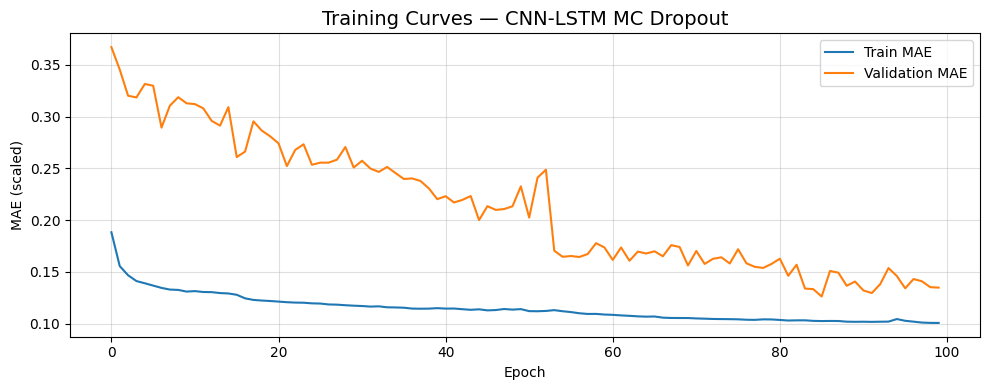

In [18]:
# ── Plot 1: Training & Validation Loss Curves
# Healthy: both curves fall and converge close together
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history.history["loss"],     label="Train MAE")
ax.plot(history.history["val_loss"], label="Validation MAE")
ax.set_title("Training Curves — CNN-LSTM MC Dropout", fontsize=14)
ax.set_xlabel("Epoch")
ax.set_ylabel("MAE (scaled)")
ax.legend()
ax.grid(True, alpha=0.4)
fig.tight_layout()
fig.savefig(OUT_DIR / "training_curves.png", dpi=150)
plt.show()

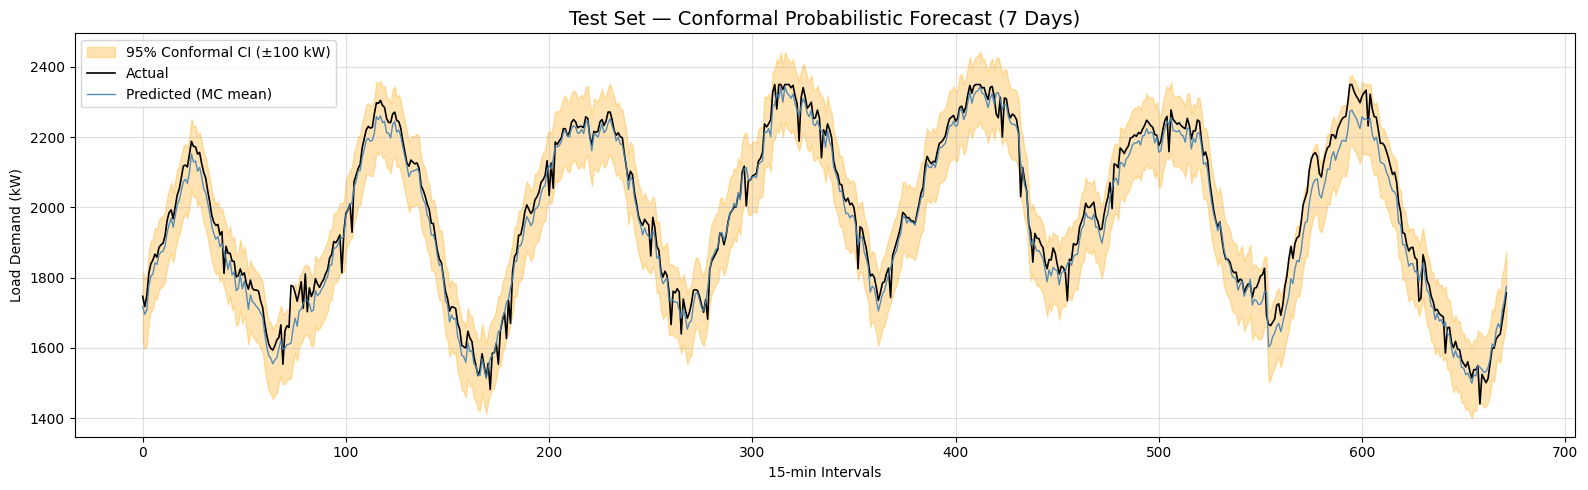

In [21]:
n_plot = min(4 * 24 * 7, len(y_te_true))  # 7 days of 15-min intervals
x_axis = np.arange(n_plot)

fig, ax = plt.subplots(figsize=(16, 5))
ax.fill_between(
    x_axis,
    y_te_lo[:n_plot, 0], # Fixed: Select first horizon step for each sample
    y_te_hi[:n_plot, 0], # Fixed: Select first horizon step for each sample
    alpha=0.3, color="orange",
    label=f"95% Conformal CI (±{q_hat:.0f} kW)"
)
ax.plot(y_te_true[:n_plot, 0], lw=1.2, color="black",     label="Actual") # Fixed: Select first horizon step for each sample
ax.plot(y_te_mean[:n_plot, 0], lw=1.0, color="steelblue", label="Predicted (MC mean)", alpha=0.9) # Fixed: Select first horizon step for each sample
ax.set_title("Test Set — Conformal Probabilistic Forecast (7 Days)", fontsize=14)
ax.set_xlabel("15-min Intervals")
ax.set_ylabel("Load Demand (kW)")
ax.legend()
ax.grid(True, alpha=0.4)
fig.tight_layout()
fig.savefig(OUT_DIR / "mc_test_predictions.png", dpi=150)
plt.show()

In [ ]:
n_unc = min(4 * 24 * 14, len(y_te_std))  # 14 days

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# Top: forecast with conformal band
axes[0].fill_between(
    np.arange(n_unc),
    y_te_lo[:n_unc, 0], # Fixed: Select first horizon step
    y_te_hi[:n_unc, 0], # Fixed: Select first horizon step
    alpha=0.25, color="orange", label="95% Conformal CI"
)
axes[0].plot(y_te_true[:n_unc, 0], lw=1.0, color="black",     label="Actual") # Fixed: Select first horizon step
axes[0].plot(y_te_mean[:n_unc, 0], lw=1.0, color="steelblue", label="MC Mean")  # Fixed: Select first horizon step
axes[0].set_ylabel("Load Demand (kW)")
axes[0].set_title("Test — Forecast + Conformal CI (14 Days)", fontsize=14)
axes[0].legend(loc="upper right")
axes[0].grid(True, alpha=0.4)

# Bottom: MC epistemic uncertainty over time
axes[1].plot(y_te_std[:n_unc, 0], color="tomato", lw=0.8, # Fixed: Select first horizon step
             label="MC std (epistemic uncertainty)")
axes[1].axhline(q_hat / 1.96, color="navy", lw=1.2, linestyle="--",
                label=f"Q_hat/1.96 = {q_hat/1.96:.0f} kW (reference threshold)")
axes[1].set_ylabel("Uncertainty std (kW)")
axes[1].set_xlabel("15-min Intervals")
axes[1].set_title("Epistemic Uncertainty — MC Dropout Std over Time", fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.4)

fig.tight_layout()
fig.savefig(OUT_DIR / "mc_uncertainty.png", dpi=150)
plt.show()

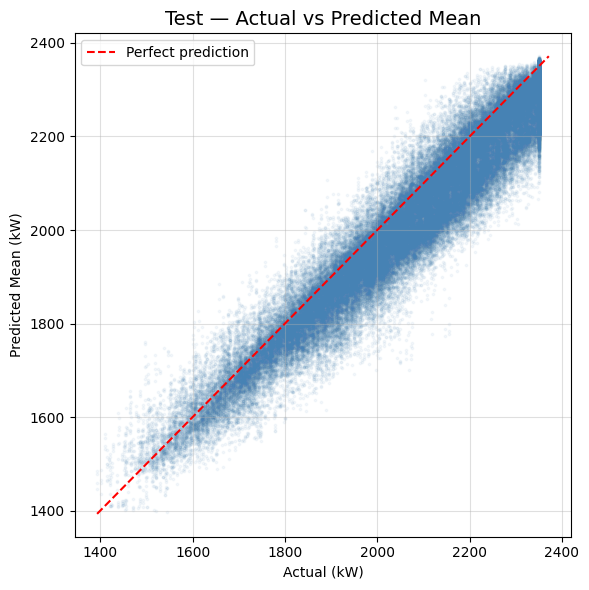

In [22]:
# ── Plot 3: Scatter — Actual vs Predicted
# Tight cluster along the red diagonal = good accuracy
# Spread = prediction error; systematic shift = bias
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_te_true.flatten(), y_te_mean.flatten(),
           alpha=0.05, s=3, color="steelblue")

lims = [
    min(y_te_true.min(), y_te_mean.min()),
    max(y_te_true.max(), y_te_mean.max()),
]
ax.plot(lims, lims, "r--", lw=1.5, label="Perfect prediction")
ax.set_title("Test — Actual vs Predicted Mean", fontsize=14)
ax.set_xlabel("Actual (kW)")
ax.set_ylabel("Predicted Mean (kW)")
ax.legend()
ax.grid(True, alpha=0.4)
fig.tight_layout()
fig.savefig(OUT_DIR / "mc_scatter.png", dpi=150)
plt.show()

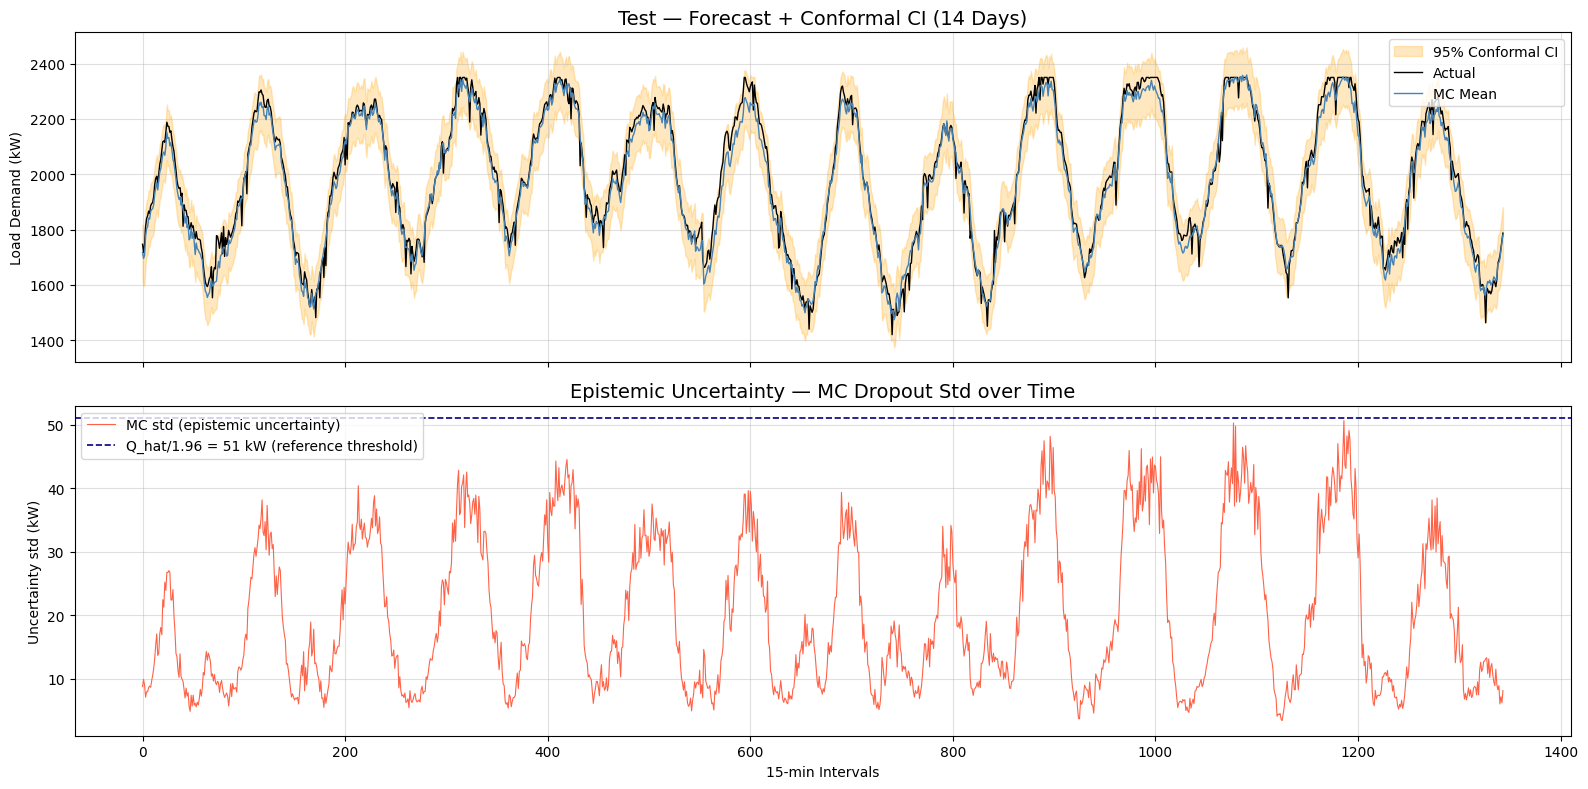

In [25]:
# ── Plot 4: 14-day forecast + epistemic uncertainty subplot
# Top panel   : actual vs MC mean with conformal band
# Bottom panel: MC std — shows WHEN the model is uncertain
# Expected pattern: higher std at peak demand hours, lower overnight
n_unc = min(4 * 24 * 14, len(y_te_std))  # 14 days

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# Top: forecast with conformal band
axes[0].fill_between(
    np.arange(n_unc),
    y_te_lo[:n_unc, 0], # Fixed: Select first horizon step
    y_te_hi[:n_unc, 0], # Fixed: Select first horizon step
    alpha=0.25, color="orange", label="95% Conformal CI"
)
axes[0].plot(y_te_true[:n_unc, 0], lw=1.0, color="black",     label="Actual") # Fixed: Select first horizon step
axes[0].plot(y_te_mean[:n_unc, 0], lw=1.0, color="steelblue", label="MC Mean")  # Fixed: Select first horizon step
axes[0].set_ylabel("Load Demand (kW)")
axes[0].set_title("Test — Forecast + Conformal CI (14 Days)", fontsize=14)
axes[0].legend(loc="upper right")
axes[0].grid(True, alpha=0.4)

# Bottom: MC epistemic uncertainty over time
axes[1].plot(y_te_std[:n_unc, 0], color="tomato", lw=0.8, # Fixed: Select first horizon step
             label="MC std (epistemic uncertainty)")
axes[1].axhline(q_hat / 1.96, color="navy", lw=1.2, linestyle="--",
                label=f"Q_hat/1.96 = {q_hat/1.96:.0f} kW (reference threshold)")
axes[1].set_ylabel("Uncertainty std (kW)")
axes[1].set_xlabel("15-min Intervals")
axes[1].set_title("Epistemic Uncertainty — MC Dropout Std over Time", fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.4)

fig.tight_layout()
fig.savefig(OUT_DIR / "mc_uncertainty.png", dpi=150)
plt.show()

## Summary & Deployment Guide

All outputs saved to the `outputs/` folder:

| File | Description |
|------|-------------|
| `best_model.keras` | Trained model weights |
| `feat_scaler.pkl` | Feature scaler |
| `target_scaler.pkl` | Target scaler |
| `training_curves.png` | Loss curves |
| `mc_test_predictions.png` | 7-day probabilistic forecast |
| `mc_scatter.png` | Scatter plot |
| `mc_uncertainty.png` | 14-day forecast + uncertainty subplot |

---

###  How to Use at Deployment

```python
# Step 1: MC inference
mean_scaled, std_scaled = mc_predict(model, X_new, n_samples=100)

# Step 2: Invert scaling
mean_kw = target_scaler.inverse_transform(mean_scaled)
std_kw  = std_scaled * target_scaler.scale_[0]

# Step 3: Apply conformal intervals (use Q_hat from calibration)
lower = mean_kw - q_hat
upper = mean_kw + q_hat
```

> **Never use `model.predict()`** at deployment — Dropout will be OFF → std = 0 → no uncertainty.